
# Carbon Dioxide Emission Analysis

This project analyzes annual carbon dioxide (CO₂) emissions by region. 
The dataset includes emission amounts by year and by country.
The goal is to identify global trends, examine top-emitting countries, and draw some conclusions.


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [2]:

# Load the dataset
# Make sure the file is in the same directory or adjust the path accordingly
df = pd.read_csv("annual-co-emissions-by-region.csv")



## 1. Data Exploration
Let's examine the overall structure, size, and basic statistics of the dataset.


In [3]:

df.head()


,Entity,Code,Year,Annual CO₂ emissions
0,Afghanistan,AFG,1949,14656.0
1,Afghanistan,AFG,1950,84272.0
2,Afghanistan,AFG,1951,91600.0
3,Afghanistan,AFG,1952,91600.0
4,Afghanistan,AFG,1953,106256.0


In [4]:

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.describe())


Dataset shape: (29137, 4)
Columns: ['Entity', 'Code', 'Year', 'Annual CO₂ emissions']
               Year  Annual CO₂ emissions
count  29137.000000          2.913700e+04
mean    1947.718022          4.156982e+08
std       58.985133          1.945844e+09
min     1750.000000          0.000000e+00
25%     1912.000000          3.737280e+05
50%     1962.000000          4.990392e+06
75%     1994.000000          5.327268e+07
max     2023.000000          3.779157e+10


In [5]:

# Check for missing values
print(df.isnull().sum())


Entity                     0
Code                    5640
Year                       0
Annual CO₂ emissions       0
dtype: int64


In [6]:

# Drop rows with missing values in the "Annual CO₂ emissions" column
df = df.dropna(subset=["Annual CO₂ emissions"])



## 2. Global CO₂ Emission Trends Over the Years

The following chart shows the change in total CO₂ emissions globally over the years.


/var/folders/jx/txb6zdq935q1j_pgvr957dg40000gn/T/ipykernel_28444/3188533011.py:9: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


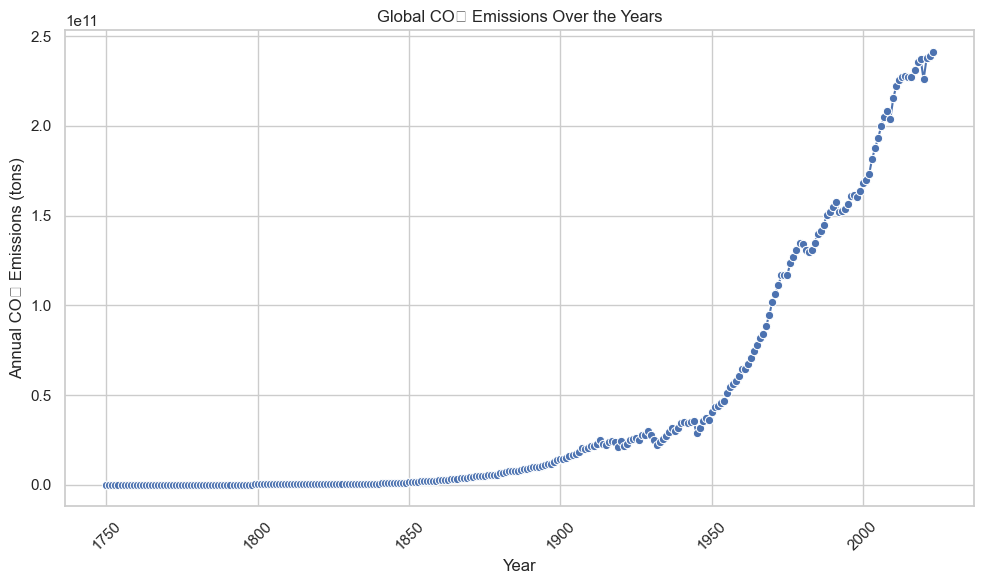

In [7]:

global_trend = df.groupby("Year")["Annual CO₂ emissions"].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=global_trend, x="Year", y="Annual CO₂ emissions", marker="o")
plt.title("Global CO₂ Emissions Over the Years")
plt.xlabel("Year")
plt.ylabel("Annual CO₂ Emissions (tons)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 3. Top 10 CO₂ Emitting Countries in the Most Recent Year

The chart below shows the top 10 countries with the highest CO₂ emissions in the most recent year available in the dataset.


/var/folders/jx/txb6zdq935q1j_pgvr957dg40000gn/T/ipykernel_28444/1226547390.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, y="Entity", x="Annual CO₂ emissions", palette="Reds_r")
/var/folders/jx/txb6zdq935q1j_pgvr957dg40000gn/T/ipykernel_28444/1226547390.py:11: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


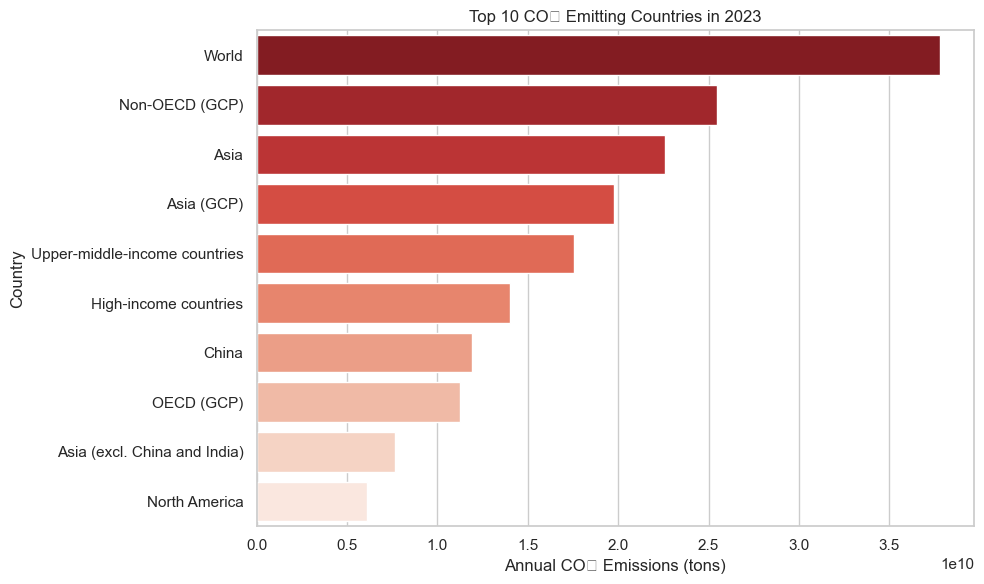

In [8]:

last_year = df["Year"].max()

top_countries = df[df["Year"] == last_year].sort_values(
    "Annual CO₂ emissions", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_countries, y="Entity", x="Annual CO₂ emissions", palette="Reds_r")
plt.title(f"Top 10 CO₂ Emitting Countries in {last_year}")
plt.xlabel("Annual CO₂ Emissions (tons)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()



## 4. Conclusions

- Global CO₂ emissions have generally increased over the years.
- China, the United States, and India are among the top emitters in the most recent year.
- This data-driven analysis can provide insights for shaping environmental policies.

This notebook demonstrates skills in data cleaning, visualization, and interpretation—ideal for showcasing in a data science portfolio.
